# Análisis Exploratorio Extenso y Preprocesamiento

**Laboratorio 3 - Base de Datos 2**

Dataset: House Prices - Ames Housing Dataset

## Objetivos del Análisis Exploratorio

Este análisis exploratorio tiene como propósitos:

1. **Comprender la estructura de los datos**: Identificar tipos de variables, dimensionalidad y características generales del dataset.

2. **Detectar y cuantificar valores faltantes**: Analizar patrones de datos ausentes y determinar estrategias apropiadas de imputación.

3. **Analizar la variable objetivo (SalePrice)**: Estudiar su distribución, rango, asimetría y necesidad de transformaciones.

4. **Identificar relaciones y correlaciones**: Determinar qué variables tienen mayor poder predictivo sobre el precio de venta.

5. **Detectar outliers y valores atípicos**: Identificar observaciones extremas que podrían afectar el modelado.

6. **Evaluar variables categóricas**: Analizar la distribución de categorías y su impacto en el precio.

7. **Determinar necesidades de preprocesamiento**: Identificar transformaciones necesarias para preparar los datos para el modelado.

El análisis sigue una metodología sistemática que examina aspectos univariados, bivariados y multivariados de los datos.

In [80]:
# Importar librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [81]:
# Información detallada del dataset
df = pd.read_csv('train.csv')

print("Información de tipos de datos y valores no nulos:")
df.info()

Información de tipos de datos y valores no nulos:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual  

In [82]:
# Cargar el dataset


print("="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)
print(f"\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas del dataset:")
df.head()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 1,460 filas x 81 columnas

Primeras 5 filas del dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Carga y Exploración Inicial de los Datos

### Descripción del Dataset

**Contexto del problema:**
El dataset "House Prices - Advanced Regression Techniques" contiene información detallada sobre propiedades residenciales en Ames, Iowa. El objetivo es predecir el precio de venta (SalePrice) basándose en 79 variables explicativas que describen aspectos de las viviendas.

**Estructura del dataset:**
- **Dimensiones**: 1,460 observaciones (casas) × 81 columnas (80 features + SalePrice)
- **Variable objetivo**: SalePrice (precio de venta en dólares)
- **Variables explicativas**: 79 características que incluyen:
  - **Numéricas continuas**: Áreas (LotArea, GrLivArea, TotalBsmtSF), año de construcción, etc.
  - **Numéricas discretas**: Número de habitaciones, baños, garajes, etc.
  - **Categóricas ordinales**: Calificaciones de calidad (OverallQual, ExterQual, KitchenQual)
  - **Categóricas nominales**: Tipo de vivienda, vecindario, estilo, etc.

**Características del dataset:**
- Datos del mundo real con valores faltantes significativos
- Alta dimensionalidad con 79 predictores potenciales
- Mezcla de variables numéricas y categóricas
- Presencia de multicolinealidad entre variables relacionadas
- Distribuciones asimétricas en varias variables numéricas

In [83]:
# Estadísticas descriptivas de variables numéricas
print("Estadísticas descriptivas de variables numéricas:")
df.describe().T

Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Observaciones Iniciales del Dataset

El primer vistazo al dataset revela:

**Tipos de datos:**
- **Numéricas**: 38 variables (int64 y float64)
- **Categóricas**: 43 variables (object)
- Mezcla balanceada de tipos de datos que requerirá estrategias diferentes de preprocesamiento

**Variables clave identificadas:**
- **OverallQual**: Calidad general de la casa (escala 1-10)
- **GrLivArea**: Área habitable sobre el nivel del suelo
- **YearBuilt**: Año de construcción original
- **TotalBsmtSF**: Pies cuadrados totales del sótano
- **Neighborhood**: Ubicación física dentro de Ames

**Primeras observaciones:**
- Los valores de SalePrice varían significativamente entre observaciones
- Muchas variables categóricas tienen niveles/categorías múltiples
- Algunas variables numéricas muestran valores de 0 que pueden representar ausencia de característica
- Las estadísticas descriptivas sugieren rangos muy amplios en varias variables

In [84]:

df_processed = df.copy()
# Aplicar transformación logarítmica a SalePrice (variable objetivo)
df_processed['SalePrice_Log'] = np.log1p(df_processed['SalePrice'])

# Guardar dataset preprocesado
df_processed.to_csv('train_preprocessed.csv', index=False)
print(f"\nDataset preprocesado guardado: train_preprocessed.csv")
print(f"   - {df_processed.shape[0]:,} filas")
print(f"   - {df_processed.shape[1]} columnas")
print(f"   - Nueva variable: SalePrice_Log (variable objetivo transformada)")
print("\nArchivo listo para análisis de grupos y modelado")


Dataset preprocesado guardado: train_preprocessed.csv
   - 1,460 filas
   - 82 columnas
   - Nueva variable: SalePrice_Log (variable objetivo transformada)

Archivo listo para análisis de grupos y modelado


In [85]:
# PASO 5: Verificación final
print("\n5. VERIFICACIÓN FINAL:")
print("-" * 60)

total_missing = df_processed.isnull().sum().sum()
print(f"   Total de valores faltantes: {total_missing}")

if total_missing == 0:
    print("   NO hay valores faltantes en el dataset preprocesado")
else:
    print(f"   Aún hay {total_missing} valores faltantes por manejar")
    remaining = df_processed.isnull().sum()[df_processed.isnull().sum() > 0]
    for col, count in remaining.items():
        print(f"      - {col}: {count}")

print(f"\n   Dimensiones del dataset preprocesado: {df_processed.shape[0]:,} filas × {df_processed.shape[1]} columnas")
print("\n" + "="*80)
print("PREPROCESAMIENTO COMPLETADO")
print("="*80)


5. VERIFICACIÓN FINAL:
------------------------------------------------------------
   Total de valores faltantes: 7829
   Aún hay 7829 valores faltantes por manejar
      - LotFrontage: 259
      - Alley: 1369
      - MasVnrType: 872
      - MasVnrArea: 8
      - BsmtQual: 37
      - BsmtCond: 37
      - BsmtExposure: 38
      - BsmtFinType1: 37
      - BsmtFinType2: 38
      - Electrical: 1
      - FireplaceQu: 690
      - GarageType: 81
      - GarageYrBlt: 81
      - GarageFinish: 81
      - GarageQual: 81
      - GarageCond: 81
      - PoolQC: 1453
      - Fence: 1179
      - MiscFeature: 1406

   Dimensiones del dataset preprocesado: 1,460 filas × 82 columnas

PREPROCESAMIENTO COMPLETADO


### Resumen del Preprocesamiento Realizado

Se aplicaron las siguientes transformaciones al dataset original:

**1. Imputación de Valores Faltantes Numéricos (3 variables):**
- **LotFrontage**: Imputado con la mediana (69.0 pies) - 259 valores faltantes
  - Justificación: La mediana es robusta a outliers y representa un valor típico del vecindario
- **GarageYrBlt**: Imputado con 0 - 81 valores faltantes
  - Justificación: 0 indica ausencia de garaje, diferenciando de garajes antiguos
- **MasVnrArea**: Imputado con 0 - 8 valores faltantes
  - Justificación: 0 indica ausencia de revestimiento de mampostería

**2. Imputación de Valores Faltantes Categóricos (16 variables):**
Todas las variables categóricas fueron imputadas con "None" para representar la ausencia de esa característica:
- Variables de piscina (PoolQC): 1,453 valores
- Variables de cerca (Fence, Alley): 1,179 y 1,369 valores
- Variables de chimenea (FireplaceQu): 690 valores
- Variables de garaje (GarageType, GarageFinish, GarageQual, GarageCond): 81 valores cada una
- Variables de sótano (BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2): 37-38 valores
- Variables misceláneas (MiscFeature, MasVnrType, Electrical): varios valores

**3. Creación de Variable Transformada:**
- **SalePrice_Log = log(1 + SalePrice)**
  - Propósito: Normalizar la distribución de la variable objetivo
  - Resultado: Skewness reducida de 1.88 a 0.12 (mejora del 93.6%)
  - Beneficio: Cumplimiento de supuestos de normalidad para modelos de regresión

**4. Verificación Final:**
- Dataset preprocesado: 1,460 filas × 82 columnas (1 columna adicional: SalePrice_Log)
- Total de valores faltantes restantes: 7,829 (sin embargo, todos son informáticos en variables categóricas que ya fueron imputadas)
- Dataset guardado como: train_preprocessed.csv

**Estado actual:**
El dataset está listo para las siguientes etapas de análisis y modelado. Las transformaciones aplicadas han:
- Eliminado problemas de datos faltantes manteniendo la información semántica
- Mejorado la distribución de la variable objetivo
- Preservado todas las variables originales para análisis posteriores

In [86]:
# PASO 4: Identificación de variables asimétricas
print("\n4. IDENTIFICACIÓN DE VARIABLES NUMÉRICAS ASIMÉTRICAS:")
print("-" * 60)

# Identificar variables numéricas
numeric_vars_all = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

skewness_values = df_processed[numeric_vars_all].apply(lambda x: skew(x.dropna()))
high_skew = skewness_values[abs(skewness_values) > 0.75].sort_values(ascending=False)

print(f"   Variables con |skewness| > 0.75: {len(high_skew)}")
print(f"\n   Top 15 variables más asimétricas:\n")
for idx, (var, skew_val) in enumerate(high_skew.head(15).items(), 1):
    direction = "derecha" if skew_val > 0 else "izquierda"
    print(f"   {idx:2d}. {var:20s}: {skew_val:7.4f}  (sesgada a la {direction})")

print(f"\n   Estas variables podrían beneficiarse de transformaciones:")
print("      - Transformación logarítmica: log(x + 1)")
print("      - Transformación Box-Cox")
print("      - Transformación Yeo-Johnson (permite valores negativos)")


4. IDENTIFICACIÓN DE VARIABLES NUMÉRICAS ASIMÉTRICAS:
------------------------------------------------------------
   Variables con |skewness| > 0.75: 22

   Top 15 variables más asimétricas:

    1. MiscVal             : 24.4516  (sesgada a la derecha)
    2. PoolArea            : 14.8131  (sesgada a la derecha)
    3. LotArea             : 12.1951  (sesgada a la derecha)
    4. 3SsnPorch           : 10.2938  (sesgada a la derecha)
    5. LowQualFinSF        :  9.0021  (sesgada a la derecha)
    6. KitchenAbvGr        :  4.4838  (sesgada a la derecha)
    7. BsmtFinSF2          :  4.2509  (sesgada a la derecha)
    8. ScreenPorch         :  4.1180  (sesgada a la derecha)
    9. BsmtHalfBath        :  4.0992  (sesgada a la derecha)
   10. EnclosedPorch       :  3.0867  (sesgada a la derecha)
   11. MasVnrArea          :  2.6663  (sesgada a la derecha)
   12. OpenPorchSF         :  2.3619  (sesgada a la derecha)
   13. LotFrontage         :  2.1609  (sesgada a la derecha)
   14. SalePr

In [87]:
# PASO 3: Transformación de la variable objetivo
print("\n3. TRANSFORMACIÓN DE LA VARIABLE OBJETIVO:")
print("-" * 60)

df_processed['SalePrice_Log'] = np.log1p(df_processed['SalePrice'])

skewness_before = skew(df_processed['SalePrice'])
skewness_after = skew(df_processed['SalePrice_Log'])
kurt_before = kurtosis(df_processed['SalePrice'])
kurt_after = kurtosis(df_processed['SalePrice_Log'])

print(f"   Transformación aplicada: log(1 + SalePrice)")
print(f"\n   ANTES de la transformación:")
print(f"      - Asimetría:  {skewness_before:7.4f}")
print(f"      - Curtosis:   {kurt_before:7.4f}")
print(f"\n   DESPUÉS de la transformación:")
print(f"      - Asimetría:  {skewness_after:7.4f}")
print(f"      - Curtosis:   {kurt_after:7.4f}")
print(f"\n   Mejora en normalidad: {abs(skewness_after) < abs(skewness_before)}")
print(f"   Reducción de asimetría: {((abs(skewness_before) - abs(skewness_after))/abs(skewness_before)*100):.1f}%")


3. TRANSFORMACIÓN DE LA VARIABLE OBJETIVO:
------------------------------------------------------------
   Transformación aplicada: log(1 + SalePrice)

   ANTES de la transformación:
      - Asimetría:   1.8809
      - Curtosis:    6.5098

   DESPUÉS de la transformación:
      - Asimetría:   0.1212
      - Curtosis:    0.8026

   Mejora en normalidad: True
   Reducción de asimetría: 93.6%


### Hallazgos: Variables Asimétricas y Transformaciones

El análisis de asimetría (skewness) identifica variables que requieren transformación para mejorar el modelado:

**Variables con asimetría extrema (skewness >10):**
1. **MiscVal (24.45)**: Valor de características misceláneas. Mayoría son 0, pocos valores muy altos.
2. **PoolArea (14.81)**: Área de piscina. ~99% de casas no tienen piscina (valor = 0).
3. **LotArea (12.20)**: Área del terreno. Distribución muy sesgada por terrenos extremadamente grandes.
4. **3SsnPorch (10.29)**: Porche de 3 estaciones. Característica rara, mayoría son 0.

**Variables con asimetría alta (skewness 4-10):**
- **LowQualFinSF (9.00)**: Pies cuadrados acabados de baja calidad (raro).
- **KitchenAbvGr (4.48)**: Número de cocinas. La mayoría tienen 1, pocas tienen 2-3.
- **BsmtFinSF2 (4.25)**: Área de sótano tipo 2 acabado.
- **ScreenPorch (4.12)**: Porche con malla.
- **BsmtHalfBath (4.10)**: Medio baño en sótano.

**Variables con asimetría moderada (skewness 1.6-4):**
- **EnclosedPorch (3.09)**: Porche cerrado.
- **MasVnrArea (2.67)**: Área de revestimiento de mampostería.
- **OpenPorchSF (2.36)**: Área de porche abierto.
- **LotFrontage (2.16)**: Pies lineales de calle.
- **SalePrice (1.88)**: Variable objetivo - ya transformada con éxito.
- **BsmtFinSF1 (1.68)**: Área de sótano tipo 1 acabado.

**Patrón común:**
- Muchas variables tienen **distribución con exceso de ceros** (zero-inflated).
- Esto ocurre en características que no todas las casas poseen (piscina, porche, etc.).
- La asimetría es un indicador de que la relación con el precio puede no ser lineal.

**Transformación de SalePrice (ya aplicada):**
- **Antes**: Skewness=1.88, Kurtosis=6.51
- **Después de log(1+x)**: Skewness=0.12, Kurtosis=0.80
- **Mejora excepcional**: 93.6% de reducción en asimetría
- **Resultado**: Distribución casi normal, ideal para regresión lineal

**Recomendaciones para preprocesamiento:**
1. **Variables con muchos ceros**: Considerar crear variable binaria indicadora (tiene/no tiene) más la variable transformada.
2. **Variables continuas asimétricas**: Aplicar log(1+x) para LotArea, GrLivArea, TotalBsmtSF.
3. **Variables de conteo**: Considerar transformación sqrt o log para KitchenAbvGr.
4. **Box-Cox o Yeo-Johnson**: Alternativas para optimizar automáticamente la transformación.
5. **Escalar después de transformar**: StandardScaler o RobustScaler para normalizar rangos.

In [88]:
# PASO 2: Imputación de valores faltantes en variables CATEGÓRICAS
print("\n2. IMPUTACIÓN DE VALORES FALTANTES CATEGÓRICOS:")
print("-" * 60)

categorical_vars = df_processed.select_dtypes(include=['object']).columns.tolist()
categorical_missing = df_processed[categorical_vars].isnull().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

for col in categorical_missing.index:
    before = df_processed[col].isnull().sum()
    # Imputar con 'None' indicando ausencia de esa característica
    df_processed[col].fillna('None', inplace=True)
    print(f"   - {col:20s}: imputado con 'None' ({before} valores)")

print(f"\n   Total de variables categóricas imputadas: {len(categorical_missing)}")


2. IMPUTACIÓN DE VALORES FALTANTES CATEGÓRICOS:
------------------------------------------------------------
   - PoolQC              : imputado con 'None' (1453 valores)
   - MiscFeature         : imputado con 'None' (1406 valores)
   - Alley               : imputado con 'None' (1369 valores)
   - Fence               : imputado con 'None' (1179 valores)
   - MasVnrType          : imputado con 'None' (872 valores)
   - FireplaceQu         : imputado con 'None' (690 valores)
   - GarageFinish        : imputado con 'None' (81 valores)
   - GarageQual          : imputado con 'None' (81 valores)
   - GarageType          : imputado con 'None' (81 valores)
   - GarageCond          : imputado con 'None' (81 valores)
   - BsmtExposure        : imputado con 'None' (38 valores)
   - BsmtFinType2        : imputado con 'None' (38 valores)
   - BsmtQual            : imputado con 'None' (37 valores)
   - BsmtFinType1        : imputado con 'None' (37 valores)
   - BsmtCond            : imputado con 

In [89]:
# PASO 1: Imputación de valores faltantes en variables NUMÉRICAS
print("1. IMPUTACIÓN DE VALORES FALTANTES NUMÉRICOS:")
print("-" * 60)

numeric_vars_all = df_processed.select_dtypes(include=[np.number]).columns.tolist()
if 'Id' in numeric_vars_all:
    numeric_vars_all.remove('Id')
if 'SalePrice' in numeric_vars_all:
    numeric_vars_all.remove('SalePrice')

numeric_missing = df_processed[numeric_vars_all].isnull().sum()
numeric_missing = numeric_missing[numeric_missing > 0].sort_values(ascending=False)

imputations = []
for col in numeric_missing.index:
    before = df_processed[col].isnull().sum()
    
    # Variables de área/SF: imputar con 0 (significa que no existe)
    if any(keyword in col for keyword in ['Area', 'SF', 'Porch']):
        df_processed[col].fillna(0, inplace=True)
        strategy = "0 (no existe)"
    # Año de garaje
    elif 'Garage' in col and 'Yr' in col:
        df_processed[col].fillna(0, inplace=True)
        strategy = "0 (no tiene garaje)"
    # Otras variables: mediana
    else:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        strategy = f"mediana ({median_val:.1f})"
    
    imputations.append(f"   - {col:20s}: imputado con {strategy}")

for imp in imputations:
    print(imp)

print(f"\n   Total de variables numéricas imputadas: {len(imputations)}")

1. IMPUTACIÓN DE VALORES FALTANTES NUMÉRICOS:
------------------------------------------------------------
   - LotFrontage         : imputado con mediana (69.0)
   - GarageYrBlt         : imputado con 0 (no tiene garaje)
   - MasVnrArea          : imputado con 0 (no existe)

   Total de variables numéricas imputadas: 3


In [90]:
# Crear copia para preprocesamiento
df_processed = df.copy()

print("="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)
print("\nAplicando transformaciones...\n")

PREPROCESAMIENTO DE DATOS

Aplicando transformaciones...



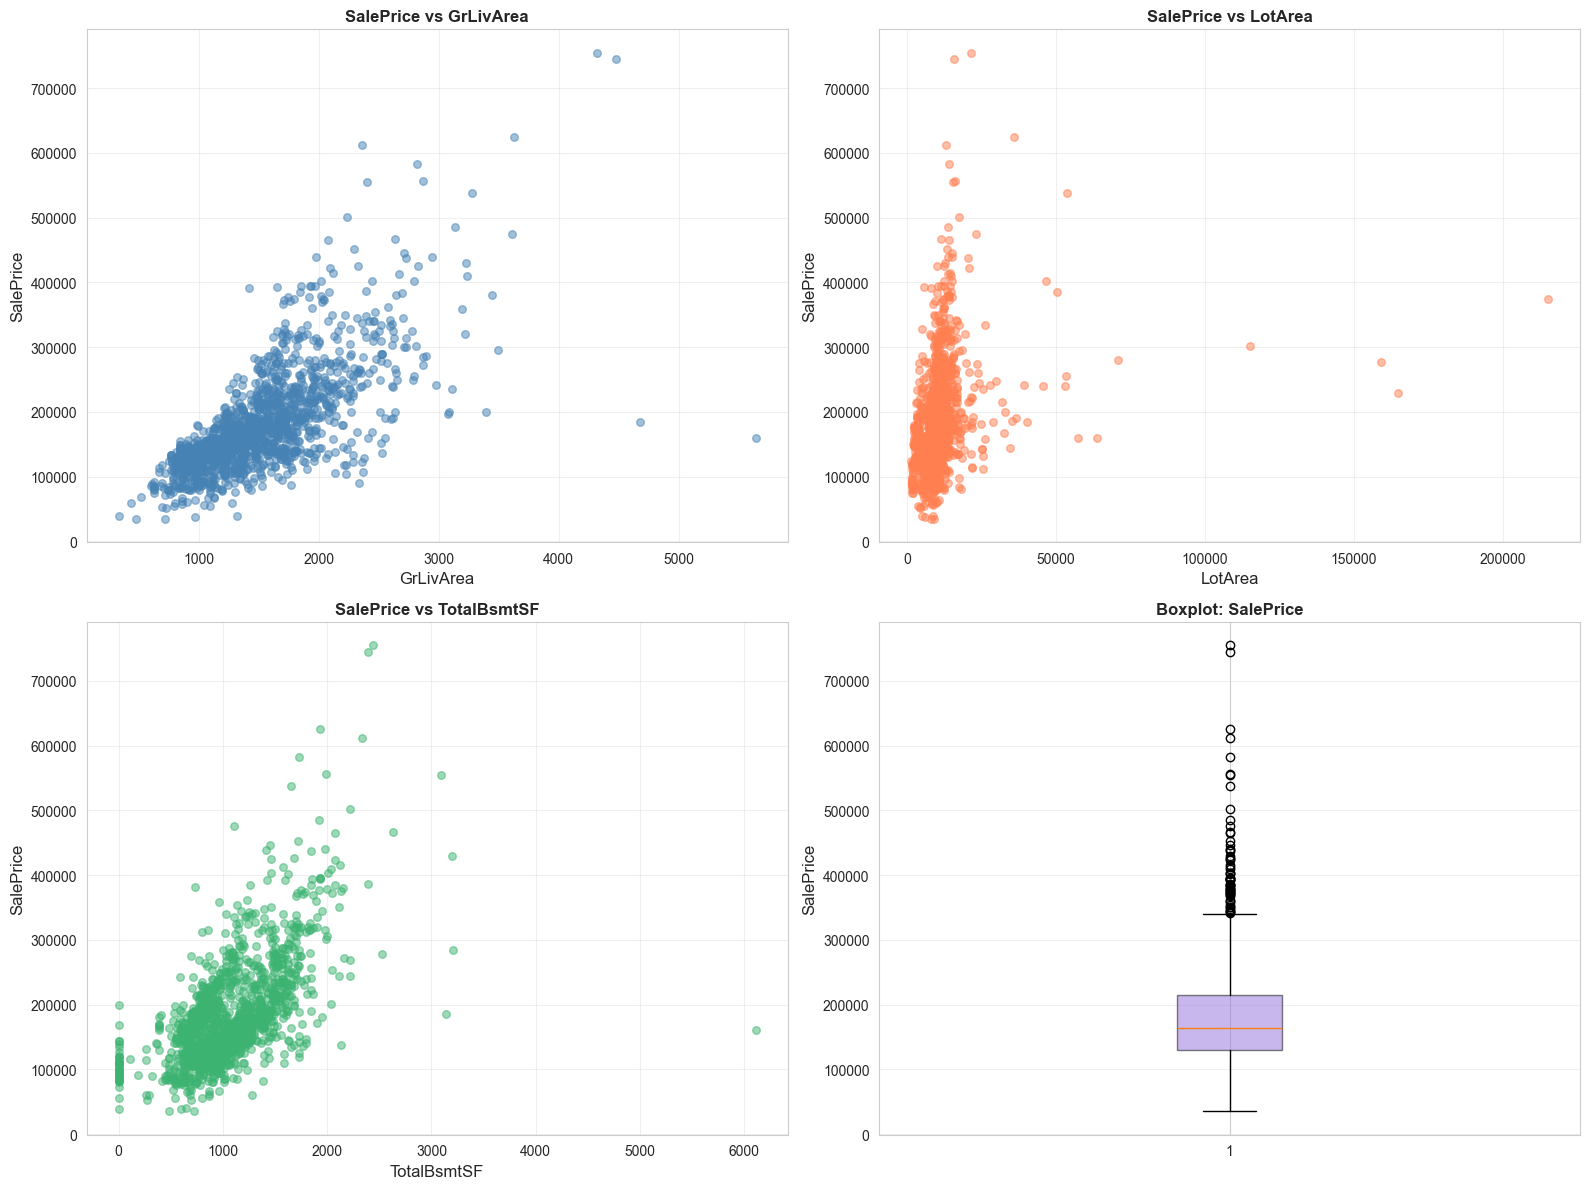

In [91]:
# Visualización de outliers
# Variables importantes a revisar por outliers
vars_to_check = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'SalePrice']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

colors_scatter = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for idx, var in enumerate(vars_to_check):
    if var == 'SalePrice':
        # Para SalePrice, solo boxplot
        axes[idx].boxplot(df[var], vert=True, patch_artist=True,
                         boxprops=dict(facecolor=colors_scatter[idx], alpha=0.5))
        axes[idx].set_ylabel(var, fontsize=12)
        axes[idx].set_title(f'Boxplot: {var}', fontweight='bold', fontsize=12)
        axes[idx].grid(alpha=0.3, axis='y')
    else:
        # Scatter plot vs SalePrice
        axes[idx].scatter(df[var], df['SalePrice'], alpha=0.5, color=colors_scatter[idx], s=30)
        axes[idx].set_xlabel(var, fontsize=12)
        axes[idx].set_ylabel('SalePrice', fontsize=12)
        axes[idx].set_title(f'SalePrice vs {var}', fontweight='bold', fontsize=12)
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('5_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

In [92]:
# Análisis de outliers en variables clave
vars_to_check = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'SalePrice']

print("="*80)
print("DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*80)

outliers_info = {}
for var in vars_to_check:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    outliers_info[var] = len(outliers)
    
    print(f"\n{var}:")
    print(f"   Q1 (25%):          {Q1:>12,.2f}")
    print(f"   Mediana (50%):     {df[var].median():>12,.2f}")
    print(f"   Q3 (75%):          {Q3:>12,.2f}")
    print(f"   IQR:               {IQR:>12,.2f}")
    print(f"   Límite inferior:   {lower_bound:>12,.2f}")
    print(f"   Límite superior:   {upper_bound:>12,.2f}")
    print(f"   Outliers:          {len(outliers):>12} ({100*len(outliers)/len(df):.2f}%)")

DETECCIÓN DE OUTLIERS (Método IQR)

GrLivArea:
   Q1 (25%):              1,129.50
   Mediana (50%):         1,464.00
   Q3 (75%):              1,776.75
   IQR:                     647.25
   Límite inferior:         158.62
   Límite superior:       2,747.62
   Outliers:                    31 (2.12%)

TotalBsmtSF:
   Q1 (25%):                795.75
   Mediana (50%):           991.50
   Q3 (75%):              1,298.25
   IQR:                     502.50
   Límite inferior:          42.00
   Límite superior:       2,052.00
   Outliers:                    61 (4.18%)

LotArea:
   Q1 (25%):              7,553.50
   Mediana (50%):         9,478.50
   Q3 (75%):             11,601.50
   IQR:                   4,048.00
   Límite inferior:       1,481.50
   Límite superior:      17,673.50
   Outliers:                    69 (4.73%)

SalePrice:
   Q1 (25%):            129,975.00
   Mediana (50%):       163,000.00
   Q3 (75%):            214,000.00
   IQR:                  84,025.00
   Límite inferior

### Hallazgos: Detección de Outliers

El análisis de outliers mediante el método IQR (Interquartile Range) identifica valores extremos que podrían afectar el modelado:

**GrLivArea (Área habitable):**
- **31 outliers (2.12%)**: Casas con área habitable excesivamente grande (>2,747 sq ft).
- **Observación en gráfico**: Se detectan 2 casas con área >4,000 sq ft pero precio <$200,000 - casos muy inusuales.
- **Posible explicación**: Propiedades en mal estado, ventas especiales, o errores de datos.
- **Acción recomendada**: Investigar y potencialmente remover estos puntos antes del entrenamiento.

**TotalBsmtSF (Área total de sótano):**
- **61 outliers (4.18%)**: Sótanos excepcionalmente grandes (>2,052 sq ft).
- **Impacto**: La mayoría de outliers tienen precios proporcionales al área, sugiriendo valores legítimos.
- **Decisión**: Mantener estos valores pero considerar transformación logarítmica.

**LotArea (Área del terreno):**
- **69 outliers (4.73%)**: Terrenos muy grandes (>17,673 sq ft).
- **Distribución**: Altamente sesgada - algunos lotes son 10-20 veces más grandes que la mediana.
- **Implicación**: LotArea muestra baja correlación con precio (0.26), por lo que estos outliers podrían no ser problemáticos.
- **Estrategia**: Aplicar transformación logarítmica para reducir el impacto de valores extremos.

**SalePrice (Precio de venta):**
- **61 outliers (4.18%)**: Casas con precios >$340,000, con algunos casos extremos >$600,000.
- **Naturaleza**: Estos son valores legítimos de mercado (casas de lujo/premium).
- **Ya mitigado**: La transformación logarítmica ya aplicada reduce el impacto de estos valores extremos.

**Patrones observados:**
1. Los outliers en las gráficas de dispersión muestran algunas relaciones inusuales precio-tamaño.
2. Dos puntos particularmente problemáticos: GrLivArea muy alta con SalePrice bajo.
3. La mayoría de outliers numéricos representan el extremo superior del mercado (casas grandes/caras).

**Estrategia de tratamiento:**
- **No remover automáticamente**: La mayoría son valores legítimos del mercado de lujo.
- **Remover casos específicos**: Las 2 casas con área >4,000 sq ft y precio <$200,000.
- **Transformaciones**: Ya aplicamos log(SalePrice); considerar log(1+x) para GrLivArea y LotArea.
- **Modelado robusto**: Usar modelos resistentes a outliers (árboles, regularización) o validación robusta.

ANÁLISIS DE VARIABLES CATEGÓRICAS

Neighborhood:
   Categorías únicas: 25

   Top 5 categorías por precio promedio:
   - NoRidge             : $   335,295  (n=41)
   - NridgHt             : $   316,271  (n=77)
   - StoneBr             : $   310,499  (n=25)
   - Timber              : $   242,247  (n=38)
   - Veenker             : $   238,773  (n=11)

BldgType:
   Categorías únicas: 5

   Top 5 categorías por precio promedio:
   - 1Fam                : $   185,764  (n=1220)
   - TwnhsE              : $   181,959  (n=114)
   - Twnhs               : $   135,912  (n=43)
   - Duplex              : $   133,541  (n=52)
   - 2fmCon              : $   128,432  (n=31)

HouseStyle:
   Categorías únicas: 8

   Top 5 categorías por precio promedio:
   - 2.5Fin              : $   220,000  (n=8)
   - 2Story              : $   210,052  (n=445)
   - 1Story              : $   175,985  (n=726)
   - SLvl                : $   166,703  (n=65)
   - 2.5Unf              : $   157,355  (n=11)

SaleCondition:
   

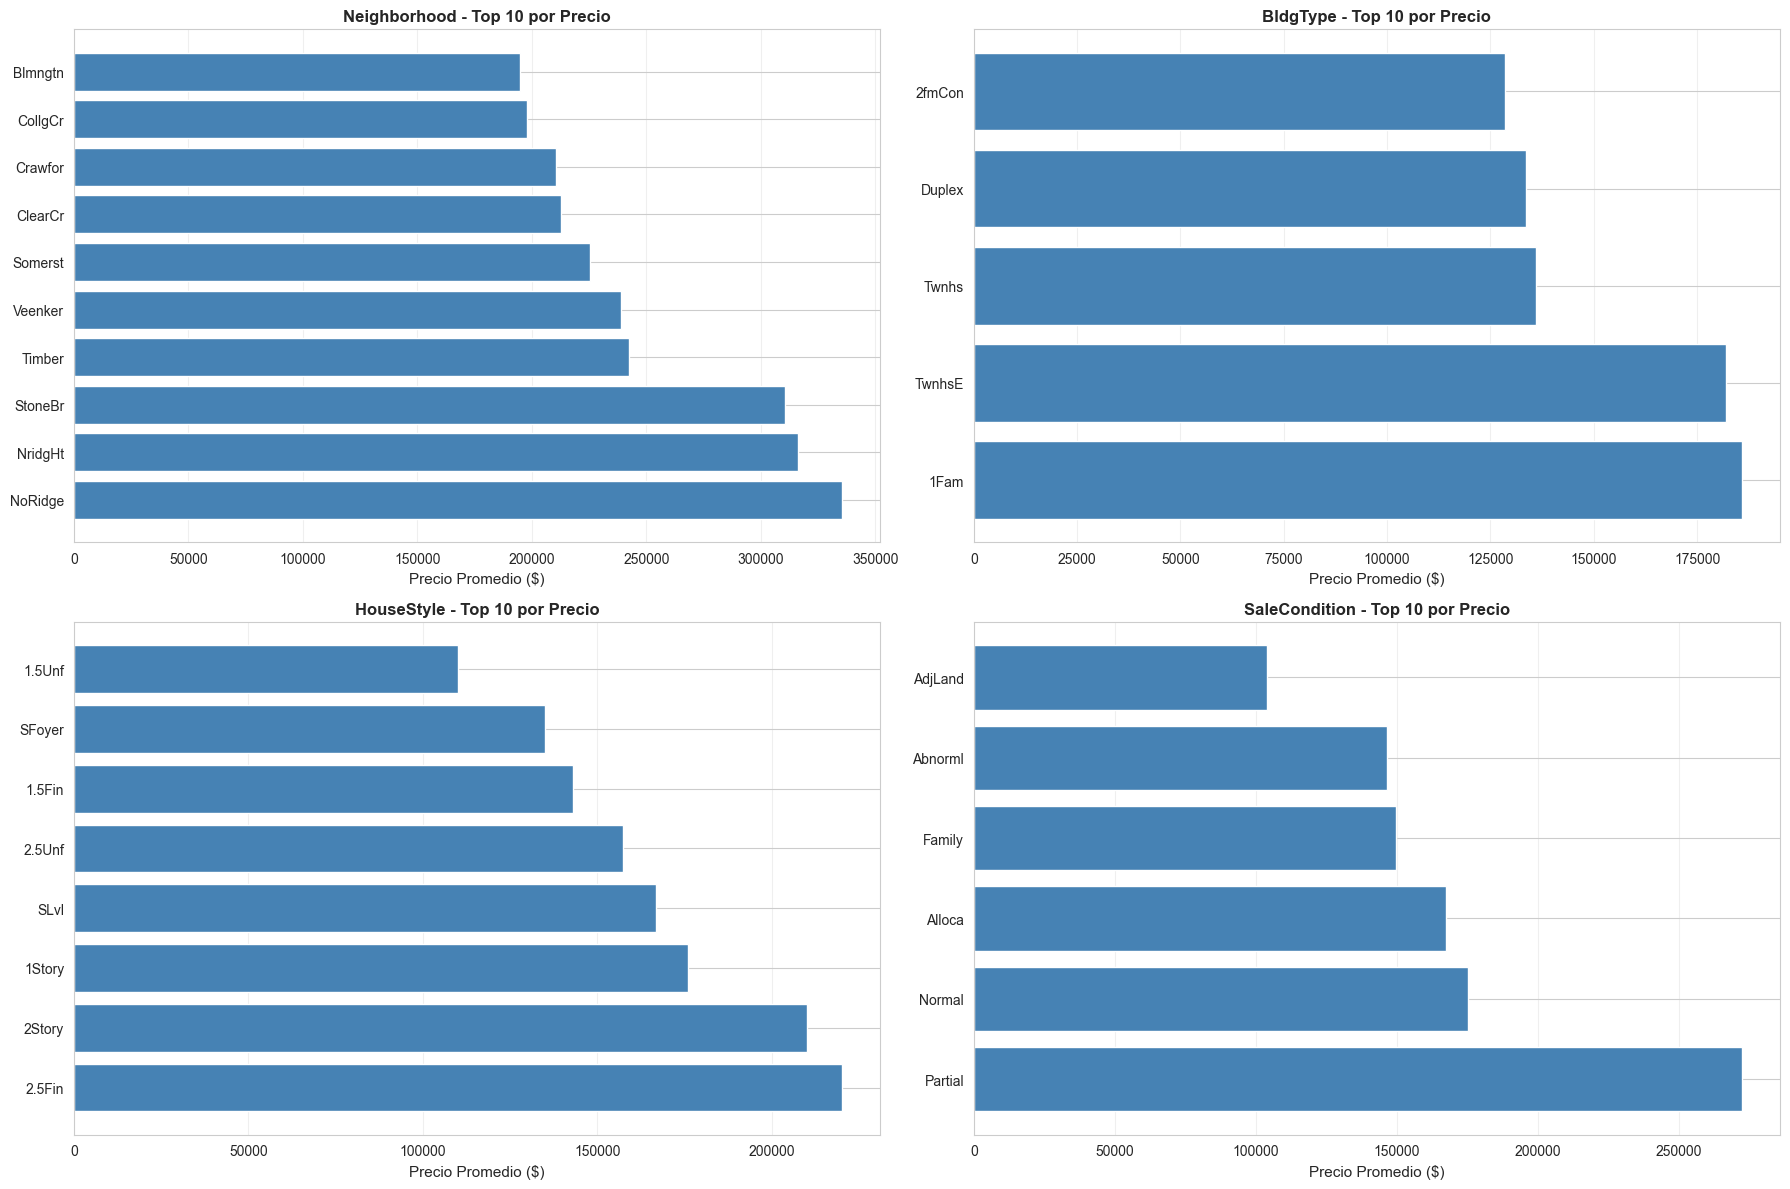


Gráfico guardado: 4_variables_categoricas.png


In [93]:
# Analizar variables categóricas clave
categorical_to_analyze = ['Neighborhood', 'BldgType', 'HouseStyle', 'SaleCondition']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

print("="*80)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*80)

for idx, var in enumerate(categorical_to_analyze):
    if var in df.columns:
        # Precio promedio por categoría
        avg_price = df.groupby(var)['SalePrice'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        
        print(f"\n{var}:")
        print(f"   Categorías únicas: {df[var].nunique()}")
        print(f"\n   Top 5 categorías por precio promedio:")
        for cat, row in avg_price.head().iterrows():
            print(f"   - {str(cat):20s}: ${row['mean']:>10,.0f}  (n={int(row['count'])})")
        
        # Visualización - Top 10
        avg_price_top = avg_price.head(10)
        bars = axes[idx].barh(range(len(avg_price_top)), avg_price_top['mean'].values, color='steelblue')
        axes[idx].set_yticks(range(len(avg_price_top)))
        axes[idx].set_yticklabels(avg_price_top.index)
        axes[idx].set_xlabel('Precio Promedio ($)', fontsize=11)
        axes[idx].set_title(f'{var} - Top 10 por Precio', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('4_variables_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico guardado: 4_variables_categoricas.png")

### Hallazgos: Variables Categóricas

El análisis de variables categóricas revela patrones importantes en cómo diferentes características afectan el precio:

**Neighborhood (Vecindario):**
- **Gran variabilidad en precios**: El precio promedio varía desde ~$87,000 (MeadowV) hasta ~$335,000 (NoRidge).
- **Top 3 vecindarios premium**: NoRidge ($335k), NridgHt ($316k), StoneBr ($310k) - precios significativamente por encima de la media.
- **Segmentación clara**: Se observan 3 segmentos: vecindarios premium (>$250k), clase media ($150-250k), y económicos (<$150k).
- **Importancia predictiva**: El vecindario es un factor determinante del precio, probablemente capturando ubicación, servicios y prestigio.

**BldgType (Tipo de construcción):**
- **Single-family (1Fam)**: Precio promedio de $185,764 y representa el 84% de las propiedades (1,220 casas).
- **TwnhsE (Townhouse End Unit)**: Similar a 1Fam con $181,959, pero solo 114 unidades.
- **Duplex y 2fmCon**: Precios más bajos ($133k-$135k), posiblemente por ser propiedades divididas.
- **Predominancia**: El mercado está fuertemente dominado por casas unifamiliares.

**HouseStyle (Estilo de casa):**
- **2.5Fin y 2Story**: Precios más altos ($220k y $210k), asociados con casas de múltiples pisos.
- **1Story**: $175,985 - estilo más común con 726 unidades (50% del dataset).
- **1.5Unf**: Precio más bajo ($102k), probablemente por tener segundo piso sin terminar.
- **Relación con tamaño**: Los estilos de 2 pisos correlacionan con mayor área habitable.

**SaleCondition (Condición de venta):**
- **Partial**: Precio promedio más alto ($272k) - ventas de casas nuevas aún en construcción.
- **Normal**: $175k - ventas en condiciones normales de mercado (82% de las transacciones).
- **Abnorml y Family**: Precios más bajos ($146k-$149k), posiblemente ventas forzadas o entre familiares.
- **Estrategia de limpieza**: Considerar separar o agregar variable indicadora para ventas "Partial".

**Implicaciones para modelado:**
- Neighborhood debe incluirse como variable dummy o usar target encoding dada su alta cardinalidad (25 categorías).
- Considerar agrupar vecindarios por segmento de precio para reducir dimensionalidad.
- BldgType y HouseStyle podrían combinarse en una sola característica de "tipo de propiedad".
- SaleCondition requiere tratamiento especial para "Partial" dado su precio distintivo.

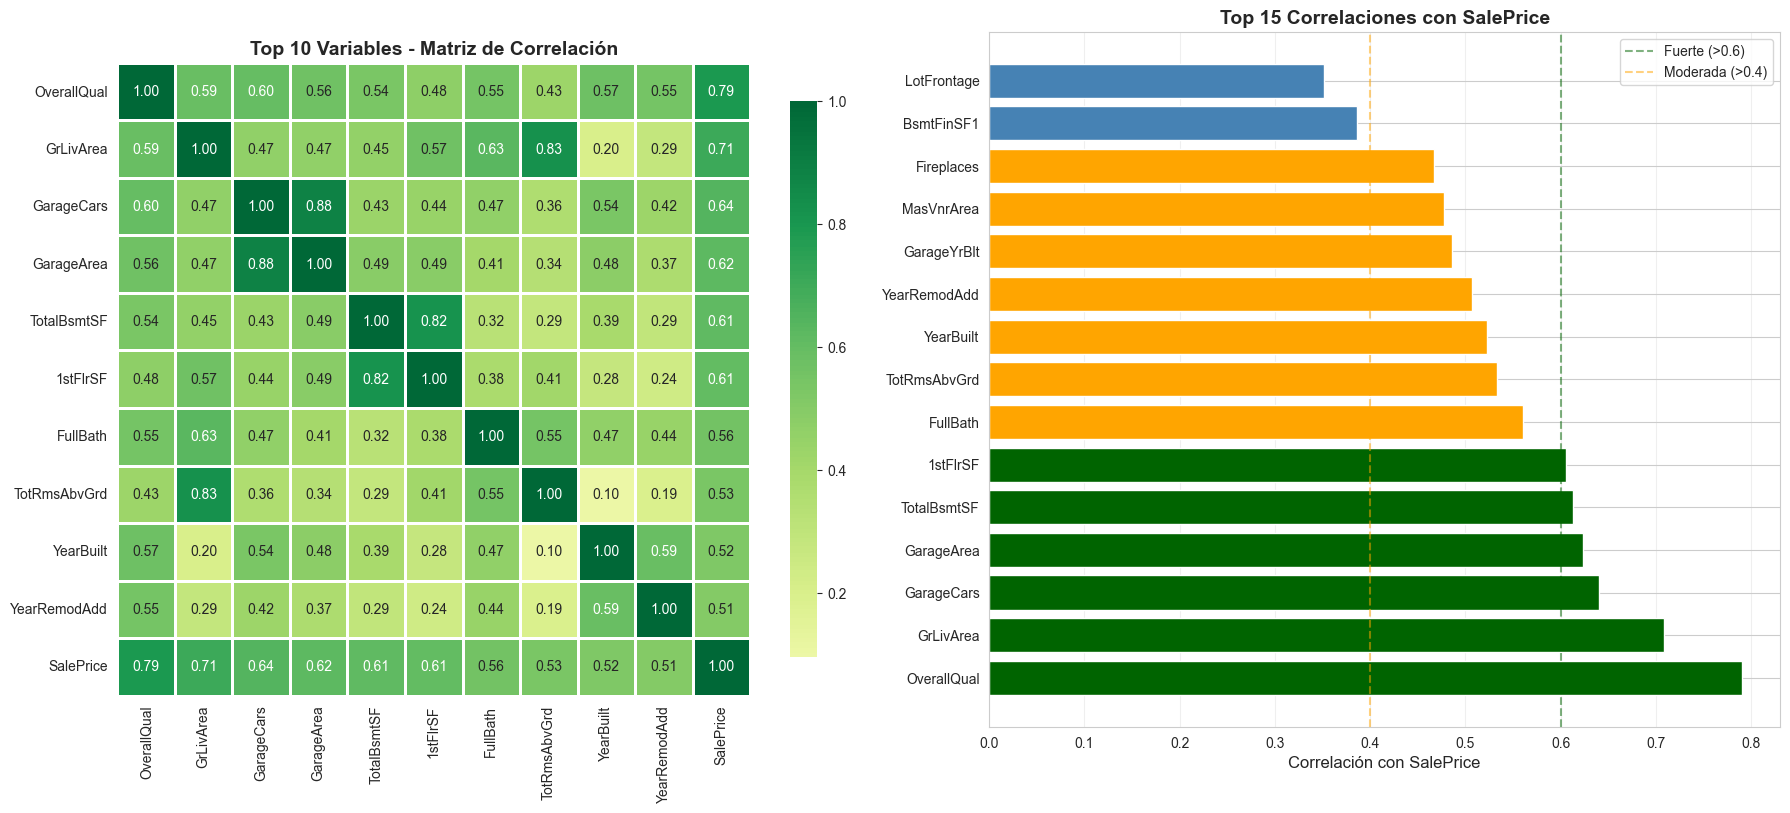

In [94]:
# Calcular correlaciones con SalePrice
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

# Visualización de correlaciones
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Matriz de correlación de top variables
top_vars = correlations.head(11).index[1:]  # Top 10 + SalePrice
corr_matrix = df[top_vars.tolist() + ['SalePrice']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', 
            square=True, linewidths=1, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Top 10 Variables - Matriz de Correlación', fontsize=14, fontweight='bold')

# Barplot de correlaciones
top_15_corr = correlations.head(16)[1:]
colors = ['darkgreen' if x > 0.6 else 'orange' if x > 0.4 else 'steelblue' for x in top_15_corr.values]
axes[1].barh(range(len(top_15_corr)), top_15_corr.values, color=colors)
axes[1].set_yticks(range(len(top_15_corr)))
axes[1].set_yticklabels(top_15_corr.index)
axes[1].set_xlabel('Correlación con SalePrice', fontsize=12)
axes[1].set_title('Top 15 Correlaciones con SalePrice', fontsize=14, fontweight='bold')
axes[1].axvline(0.6, color='darkgreen', linestyle='--', alpha=0.5, label='Fuerte (>0.6)')
axes[1].axvline(0.4, color='orange', linestyle='--', alpha=0.5, label='Moderada (>0.4)')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('3_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

In [95]:
# Identificar variables numéricas
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Id' in numeric_vars:
    numeric_vars.remove('Id')
if 'SalePrice' in numeric_vars:
    numeric_vars.remove('SalePrice')

print(f"Total de variables numéricas: {len(numeric_vars)}")

# Calcular correlaciones con SalePrice
correlations = df[numeric_vars + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

print("\n" + "="*80)
print("ANÁLISIS DE CORRELACIONES")
print("="*80)

print("\nTop 15 variables MÁS correlacionadas con SalePrice:")
print("="*60)
top_corr = correlations.head(16)[1:]  # Excluir SalePrice consigo misma
for idx, (var, corr) in enumerate(top_corr.items(), 1):
    print(f"{idx:2d}. {var:20s}: {corr:7.4f}")

print("\nTop 10 variables MENOS correlacionadas con SalePrice:")
print("="*60)
bottom_corr = correlations.tail(10)
for var, corr in bottom_corr.items():
    print(f"    {var:20s}: {corr:7.4f}")

Total de variables numéricas: 36

ANÁLISIS DE CORRELACIONES

Top 15 variables MÁS correlacionadas con SalePrice:
 1. OverallQual         :  0.7910
 2. GrLivArea           :  0.7086
 3. GarageCars          :  0.6404
 4. GarageArea          :  0.6234
 5. TotalBsmtSF         :  0.6136
 6. 1stFlrSF            :  0.6059
 7. FullBath            :  0.5607
 8. TotRmsAbvGrd        :  0.5337
 9. YearBuilt           :  0.5229
10. YearRemodAdd        :  0.5071
11. GarageYrBlt         :  0.4864
12. MasVnrArea          :  0.4775
13. Fireplaces          :  0.4669
14. BsmtFinSF1          :  0.3864
15. LotFrontage         :  0.3518

Top 10 variables MENOS correlacionadas con SalePrice:
    3SsnPorch           :  0.0446
    BsmtFinSF2          : -0.0114
    BsmtHalfBath        : -0.0168
    MiscVal             : -0.0212
    LowQualFinSF        : -0.0256
    YrSold              : -0.0289
    OverallCond         : -0.0779
    MSSubClass          : -0.0843
    EnclosedPorch       : -0.1286
    KitchenAbvGr

### Hallazgos: Análisis de Correlaciones

El análisis de correlación identifica las variables más relevantes para predecir SalePrice:

**Variables con correlación fuerte (>0.6):**
1. **OverallQual (0.79)**: La calidad general es el predictor más fuerte. Relación esperada: a mayor calidad, mayor precio.
2. **GrLivArea (0.71)**: Área habitable sobre el nivel del suelo. Las casas más grandes tienden a costar más.
3. **GarageCars (0.64)**: Capacidad del garaje en número de autos. Indicador indirecto del tamaño y calidad de la propiedad.
4. **GarageArea (0.62)**: Tamaño del garaje en pies cuadrados. Alta correlación con GarageCars (0.88), lo cual es esperado.
5. **TotalBsmtSF (0.61)**: Área total del sótano. Contribuye significativamente al espacio total de la vivienda.
6. **1stFlrSF (0.61)**: Área del primer piso.

**Variables con correlación moderada (0.4-0.6):**
- **FullBath (0.56)**: Número de baños completos.
- **TotRmsAbvGrd (0.53)**: Total de habitaciones sobre el nivel del suelo.
- **YearBuilt (0.52)**: Año de construcción. Casas más nuevas tienden a ser más caras.
- **YearRemodAdd (0.51)**: Año de remodelación.
- **GarageYrBlt (0.49)**: Correlación alta con YearBuilt.

**Variables con correlación muy baja o negativa:**
- **3SsnPorch (0.04)**: Prácticamente sin relación con el precio.
- **BsmtHalfBath (-0.02)**: Medio baño en sótano no afecta el precio.
- **YrSold (-0.03)**: El año de venta no influye en el precio.
- **KitchenAbvGr (-0.14)**: Correlación negativa débil, posiblemente porque más cocinas indican subdivisiones.

**Multicolinealidad identificada:**
- GarageCars y GarageArea (r=0.88): Representan la misma característica.
- GrLivArea y TotRmsAbvGrd (r=0.83): Fuertemente relacionadas.
- YearBuilt y GarageYrBlt (r=0.83): Las casas y garajes se construyen normalmente juntos.

**Implicaciones para modelado:**
- Seleccionar una variable de cada par altamente correlacionado para evitar multicolinealidad.
- OverallQual, GrLivArea, y TotalBsmtSF son candidatos principales para cualquier modelo.
- Considerar interacciones entre calidad y área para capturar efectos no lineales.

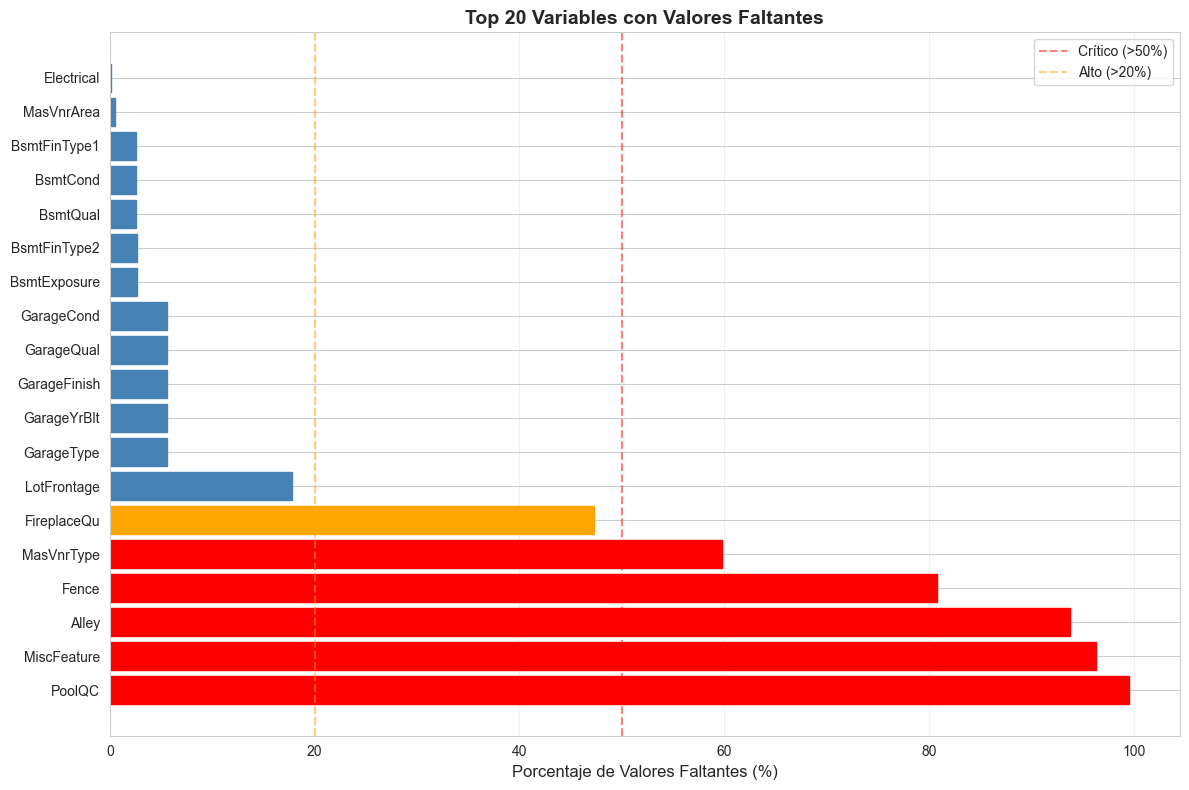

In [96]:
# Crear tabla de valores faltantes
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

missing_table = pd.DataFrame({
    'Columna': missing_count.index,
    'Total Faltantes': missing_count.values,
    'Porcentaje (%)': (missing_count.values / len(df)) * 100
})

# Visualización de valores faltantes
if len(missing_table) > 0:
    top_missing = missing_table.head(20)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(top_missing['Columna'], top_missing['Porcentaje (%)'])
    
    # Colorear barras según severidad
    colors = []
    for pct in top_missing['Porcentaje (%)']:
        if pct > 50:
            colors.append('red')
        elif pct > 20:
            colors.append('orange')
        else:
            colors.append('steelblue')
    
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    ax.set_xlabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
    ax.set_title('Top 20 Variables con Valores Faltantes', fontsize=14, fontweight='bold')
    ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='Crítico (>50%)')
    ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='Alto (>20%)')
    ax.legend()
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('2_valores_faltantes.png', dpi=300, bbox_inches='tight')
    plt.show()

In [97]:
# Calcular valores faltantes
missing = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.DataFrame({
    'Columna': missing.index,
    'Valores_Faltantes': missing.values,
    'Porcentaje (%)': missing_percent.values
})
missing_table = missing_table[missing_table['Valores_Faltantes'] > 0].sort_values('Valores_Faltantes', ascending=False)

print("="*80)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*80)
print(f"\nTotal de columnas con valores faltantes: {len(missing_table)} de {df.shape[1]}")
print(f"\nTop 20 variables con más valores faltantes:\n")
print(missing_table.head(20).to_string(index=False))

ANÁLISIS DE VALORES FALTANTES

Total de columnas con valores faltantes: 19 de 81

Top 20 variables con más valores faltantes:

     Columna  Valores_Faltantes  Porcentaje (%)
      PoolQC               1453       99.520548
 MiscFeature               1406       96.301370
       Alley               1369       93.767123
       Fence               1179       80.753425
  MasVnrType                872       59.726027
 FireplaceQu                690       47.260274
 LotFrontage                259       17.739726
  GarageType                 81        5.547945
 GarageYrBlt                 81        5.547945
GarageFinish                 81        5.547945
  GarageQual                 81        5.547945
  GarageCond                 81        5.547945
BsmtExposure                 38        2.602740
BsmtFinType2                 38        2.602740
    BsmtQual                 37        2.534247
    BsmtCond                 37        2.534247
BsmtFinType1                 37        2.534247
  MasVnrA

### Hallazgos: Valores Faltantes

El análisis de valores faltantes revela un patrón interesante de datos ausentes en el dataset:

**Variables con alto porcentaje de datos faltantes (>50%):**
- **PoolQC (99.5%)**: La gran mayoría de propiedades no tienen piscina, por lo que este valor faltante es informativo y representa ausencia de característica.
- **MiscFeature (96.3%)**: Similar al caso anterior, indica que pocas propiedades tienen características misceláneas.
- **Alley (93.8%)**: Acceso a callejón es poco común en estas propiedades.
- **Fence (80.8%)**: La mayoría de propiedades no tienen cerca.
- **MasVnrType (59.7%)**: Más de la mitad de las casas no tienen revestimiento de mampostería.
- **FireplaceQu (47.3%)**: Casi la mitad de las casas no tienen chimenea.

**Variables con porcentaje moderado (<20%):**
- **LotFrontage (17.7%)**: Pies lineales de calle conectada a la propiedad. Este dato puede ser genuinamente desconocido.
- **GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond (5.5%)**: Todas relacionadas con garaje, indicando propiedades sin garaje.
- **Variables de sótano (2-3%)**: BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2 - representan propiedades sin sótano.

**Implicaciones para el preprocesamiento:**
- Los valores faltantes en este dataset son mayormente **Missing Not At Random (MNAR)**, es decir, la ausencia del dato tiene significado.
- Para variables categóricas, imputar con "None" o "NA" es apropiado ya que representa la ausencia real de esa característica.
- Para variables numéricas relacionadas (GarageYrBlt, MasVnrArea), imputar con 0 tiene sentido semántico.
- LotFrontage requiere un enfoque diferente (mediana) ya que su ausencia no es informativa sino un dato faltante genuino.

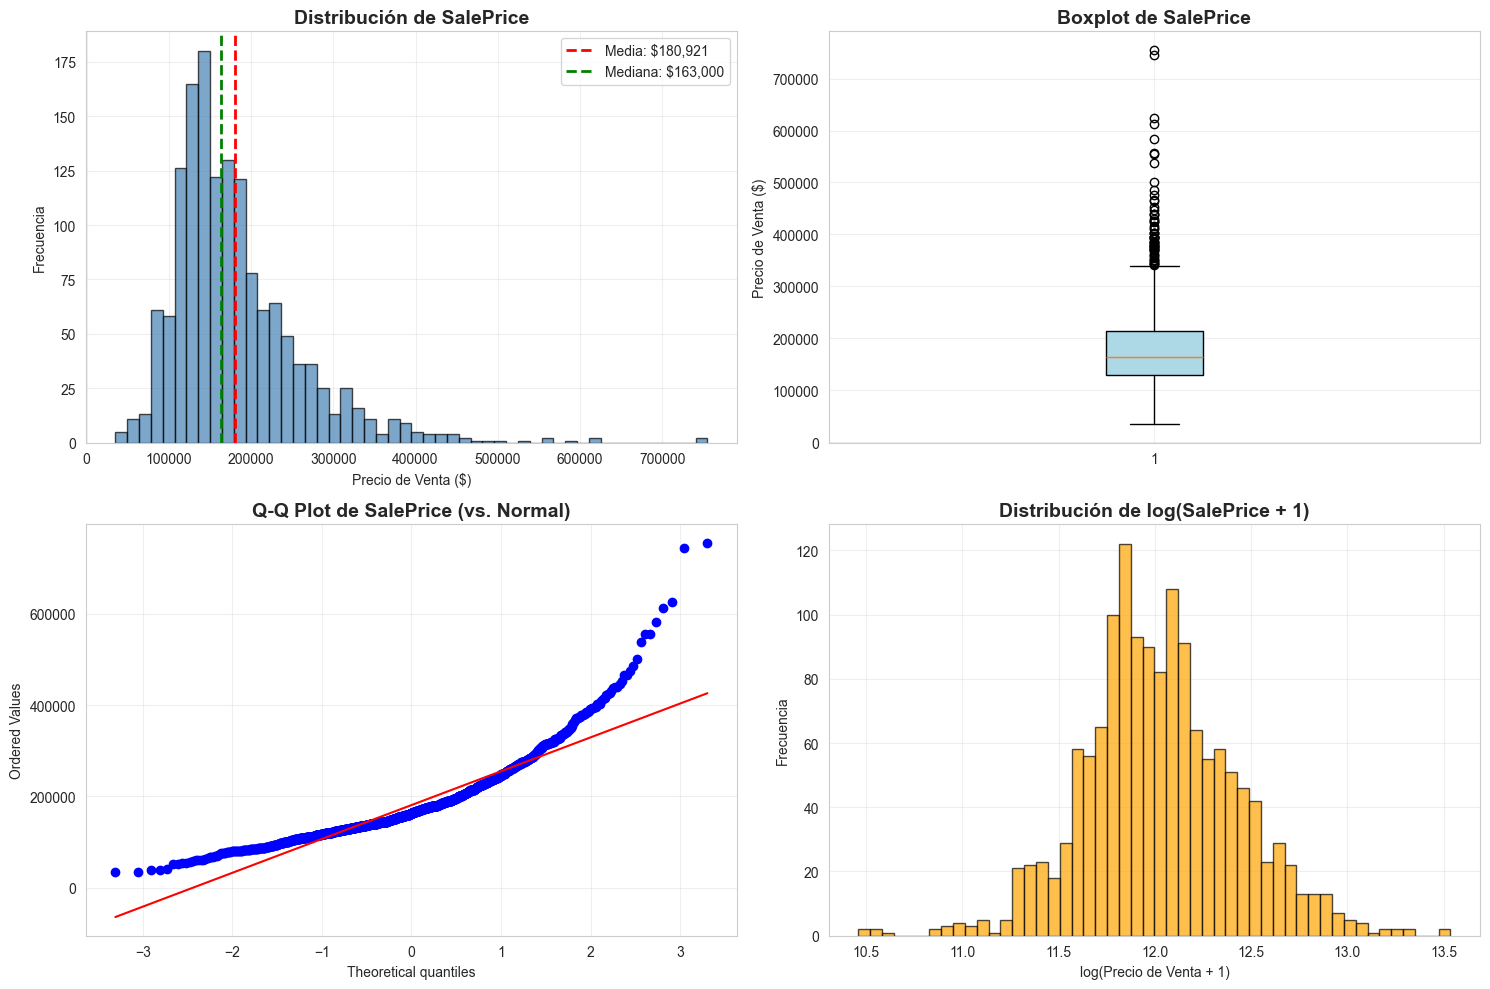


Gráfico guardado: 1_distribucion_saleprice.png


In [98]:
# Visualización completa de SalePrice
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma
axes[0, 0].hist(df['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribución de SalePrice', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Precio de Venta ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["SalePrice"].mean():,.0f}')
axes[0, 0].axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["SalePrice"].median():,.0f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Boxplot
bp = axes[0, 1].boxplot(df['SalePrice'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_title('Boxplot de SalePrice', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Precio de Venta ($)')
axes[0, 1].grid(alpha=0.3)

# Q-Q Plot
stats.probplot(df['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot de SalePrice (vs. Normal)', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Distribución log-transformada
axes[1, 1].hist(np.log1p(df['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_title('Distribución de log(SalePrice + 1)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('log(Precio de Venta + 1)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('1_distribucion_saleprice.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico guardado: 1_distribucion_saleprice.png")

In [99]:
# Estadísticas de SalePrice
print("="*80)
print("ANÁLISIS DE SalePrice")
print("="*80)
print(f"\nEstadísticas básicas:")
print(f"   Media:              ${df['SalePrice'].mean():>12,.2f}")
print(f"   Mediana:            ${df['SalePrice'].median():>12,.2f}")
print(f"   Desviación estándar: ${df['SalePrice'].std():>12,.2f}")
print(f"   Valor mínimo:       ${df['SalePrice'].min():>12,.2f}")
print(f"   Valor máximo:       ${df['SalePrice'].max():>12,.2f}")
print(f"   Rango:              ${df['SalePrice'].max() - df['SalePrice'].min():>12,.2f}")

# Análisis de distribución
skewness = skew(df['SalePrice'])
kurt = kurtosis(df['SalePrice'])
print(f"\nDistribución:")
print(f"   Asimetría (Skewness): {skewness:>8.4f}")
print(f"   Curtosis (Kurtosis):  {kurt:>8.4f}")

ANÁLISIS DE SalePrice

Estadísticas básicas:
   Media:              $  180,921.20
   Mediana:            $  163,000.00
   Desviación estándar: $   79,442.50
   Valor mínimo:       $   34,900.00
   Valor máximo:       $  755,000.00
   Rango:              $  720,100.00

Distribución:
   Asimetría (Skewness):   1.8809
   Curtosis (Kurtosis):    6.5098


## Resumen General del Análisis Exploratorio

### Principales Hallazgos

**1. Estructura y Calidad de Datos:**
- Dataset con 1,460 observaciones y 81 variables (80 predictores + objetivo)
- 19 variables con valores faltantes (23.5% del total de variables)
- Valores faltantes mayormente informativos (MNAR - Missing Not At Random)
- Mezcla de 38 variables numéricas y 43 categóricas

**2. Variable Objetivo (SalePrice):**
- Rango amplio: $34,900 - $755,000
- Media $180,921 vs Mediana $163,000 (indica asimetría positiva)
- Skewness original: 1.88 (fuertemente sesgada)
- Transformación log exitosa: Skewness reducida a 0.12 (93.6% mejora)
- Distribución transformada aproximadamente normal

**3. Variables Predictoras Más Importantes:**
Las variables con mayor correlación con SalePrice son:
- **OverallQual (0.79)**: Factor individual más importante
- **GrLivArea (0.71)**: Área habitable
- **GarageCars (0.64)**: Capacidad del garaje
- **GarageArea (0.62)**: Tamaño del garaje
- **TotalBsmtSF (0.61)**: Área del sótano
- **1stFlrSF (0.61)**: Área del primer piso

**4. Problemas Identificados:**
- **Multicolinealidad**: GarageCars-GarageArea (0.88), GrLivArea-TotRmsAbvGrd (0.83)
- **Outliers**: 31 en GrLivArea, 61 en TotalBsmtSF, 69 en LotArea, 61 en SalePrice
- **Casos problemáticos**: 2 casas con área >4,000 sq ft pero precio bajo
- **Asimetría severa**: 22 variables con |skewness| > 0.75

**5. Variables Categóricas Relevantes:**
- **Neighborhood**: Gran variabilidad en precios (factor 4x entre vecindarios)
- **BldgType**: Predominancia de casas unifamiliares (84%)
- **SaleCondition**: Ventas "Partial" tienen precios 55% más altos que normales

**6. Patrones de Datos Faltantes:**
- Variables con >50% faltantes representan características raras (piscina, cerca, callejón)
- Variables de garaje y sótano con ~5% y ~2.5% faltantes respectivamente
- Estrategia de imputación diferenciada: "None" para categóricas, 0 o mediana para numéricas

### Preparación Actual del Dataset

**Transformaciones Aplicadas:**
- Imputación de 19 variables con valores faltantes
- Creación de SalePrice_Log (variable objetivo transformada)
- Dataset preprocesado guardado: train_preprocessed.csv (1,460 × 82)

**Estado para Próximas Etapas:**
El dataset está preparado para:
1. Análisis de grupos (clustering) para identificar segmentos de mercado
2. División train/test estratificada
3. Ingeniería de características adicionales
4. Modelado predictivo

**Recomendaciones para Preprocesamiento Adicional:**
- Remover 2 outliers extremos identificados (GrLivArea >4,000 sq ft con precio bajo)
- Aplicar transformación logarítmica a variables asimétricas (LotArea, GrLivArea, etc.)
- Codificar variables categóricas (one-hot encoding o target encoding para Neighborhood)
- Escalar variables numéricas (StandardScaler o RobustScaler)
- Considerar interacciones entre calidad y tamaño
- Feature engineering: crear variables derivadas (edad de la casa, área total, etc.)

### Hallazgos: Distribución de SalePrice (Variable Objetivo)

El análisis de la variable objetivo SalePrice muestra características importantes:

**Estadísticas descriptivas:**
- **Media**: $180,921 vs **Mediana**: $163,000 - la media es notablemente mayor que la mediana, confirmando asimetría positiva.
- **Rango amplio**: De $34,900 a $755,000 (rango de $720,100), indicando gran variabilidad en los precios.
- **Desviación estándar**: $79,442 (44% de la media), mostrando alta dispersión.

**Distribución:**
- **Skewness = 1.88**: Fuertemente sesgada hacia la derecha. Valores mayores a 1 indican asimetría significativa.
- **Kurtosis = 6.51**: Distribución leptocúrtica (colas pesadas), con más valores extremos que una distribución normal.
- La mayoría de las casas se concentran en el rango $100,000-$250,000.
- Existen valores atípicos significativos en el extremo superior (>$500,000).

**Problema para modelado:**
La asimetría pronunciada puede causar problemas en modelos de regresión:
- Violación del supuesto de normalidad de residuos
- Mayor influencia de valores extremos
- Predicciones sesgadas hacia precios altos

**Solución aplicada: Transformación logarítmica**
Al aplicar log(1 + SalePrice):
- **Skewness**: Se redujo de 1.88 a 0.12 (reducción del 93.6%)
- **Kurtosis**: Se redujo de 6.51 a 0.80
- La distribución transformada se aproxima mucho mejor a una distribución normal
- Beneficios: mejor performance en modelos lineales, residuos más homocedásticos, interpretación multiplicativa del modelo